In [3]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


# Crypto Forecasting Project
# Naviotech Summer Internship Project
# Student: Sudipta Kar
# Department: Data Science
# Project Category: Time Series Forecasting

In [8]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Sudipta Kar\Downloads\btcusd_1-min_data.csv")

df.head()

,Timestamp,Open,High,Low,Close,Volume
0,1325376060,4.58,4.58,4.58,4.58,0.0
1,1325376120,4.58,4.58,4.58,4.58,0.0
2,1325376180,4.58,4.58,4.58,4.58,0.0
3,1325376240,4.58,4.58,4.58,4.58,0.0
4,1325376300,4.58,4.58,4.58,4.58,0.0


In [9]:
df.head()

,Timestamp,Open,High,Low,Close,Volume
0,1325376060,4.58,4.58,4.58,4.58,0.0
1,1325376120,4.58,4.58,4.58,4.58,0.0
2,1325376180,4.58,4.58,4.58,4.58,0.0
3,1325376240,4.58,4.58,4.58,4.58,0.0
4,1325376300,4.58,4.58,4.58,4.58,0.0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7645034 entries, 0 to 7645033
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Timestamp  int64  
 1   Open       float64
 2   High       float64
 3   Low        float64
 4   Close      float64
 5   Volume     float64
dtypes: float64(5), int64(1)
memory usage: 350.0 MB


In [11]:
df.describe()

,Timestamp,Open,High,Low,Close,Volume
count,7.645034e+06,7.645034e+06,7.645034e+06,7.645034e+06,7.645034e+06,7.645034e+06
mean,1.554727e+09,2.356862e+04,2.357683e+04,2.356024e+04,2.356864e+04,4.978422e+00
std,1.324159e+08,3.133617e+04,3.134456e+04,3.132773e+04,3.133620e+04,2.161888e+01
min,1.325376e+09,3.800000e+00,3.800000e+00,3.800000e+00,3.800000e+00,0.000000e+00
25%,1.440052e+09,4.569600e+02,4.570000e+02,4.567700e+02,4.569700e+02,2.170787e-02
50%,1.554727e+09,8.050000e+03,8.056050e+03,8.043770e+03,8.049810e+03,4.468850e-01
75%,1.669403e+09,3.854658e+04,3.856712e+04,3.852529e+04,3.854742e+04,2.782662e+00
max,1.784078e+09,1.262020e+05,1.262720e+05,1.261580e+05,1.262020e+05,5.853852e+03


In [12]:
df.isnull().sum()

Timestamp    0
Open         0
High         0
Low          0
Close        0
Volume       0
dtype: int64

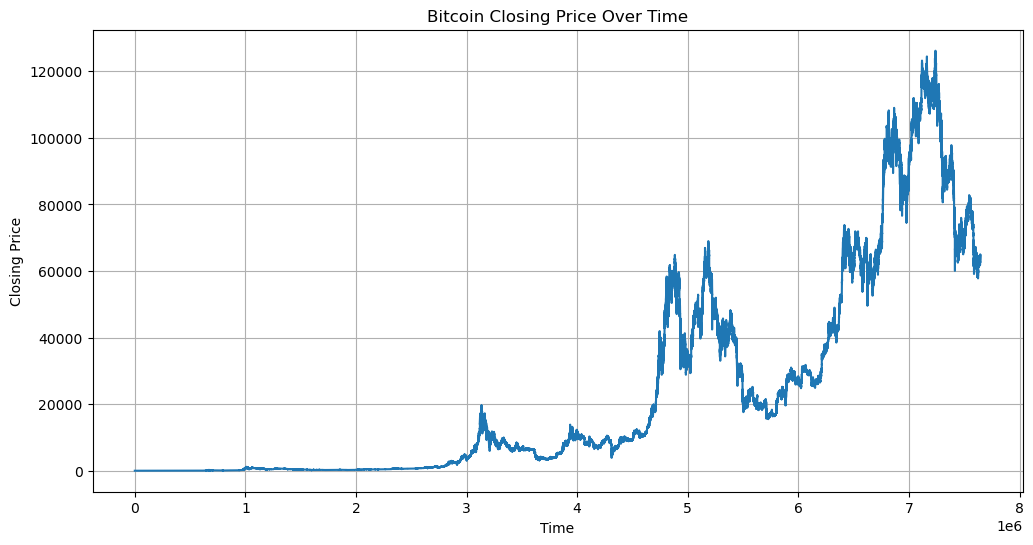

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df['Close'])
plt.title("Bitcoin Closing Price Over Time")
plt.xlabel("Time")
plt.ylabel("Closing Price")
plt.grid(True)
plt.show()

In [14]:
print(df.columns)

Index(['Timestamp', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')


C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


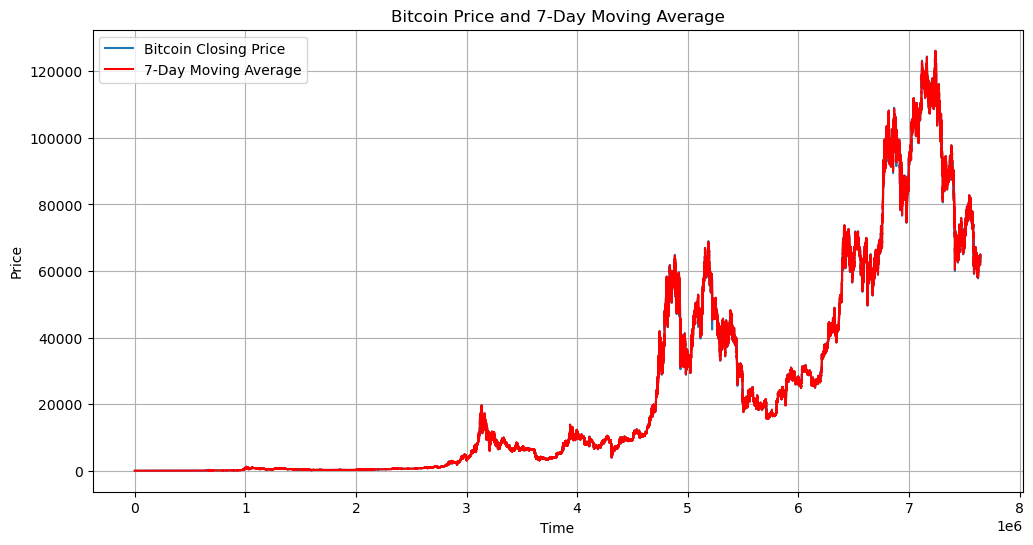

In [15]:
df['MA7'] = df['Close'].rolling(window=7).mean()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df['Close'], label='Bitcoin Closing Price')
plt.plot(df['MA7'], color='red', label='7-Day Moving Average')

plt.title("Bitcoin Price and 7-Day Moving Average")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

plt.show()

C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


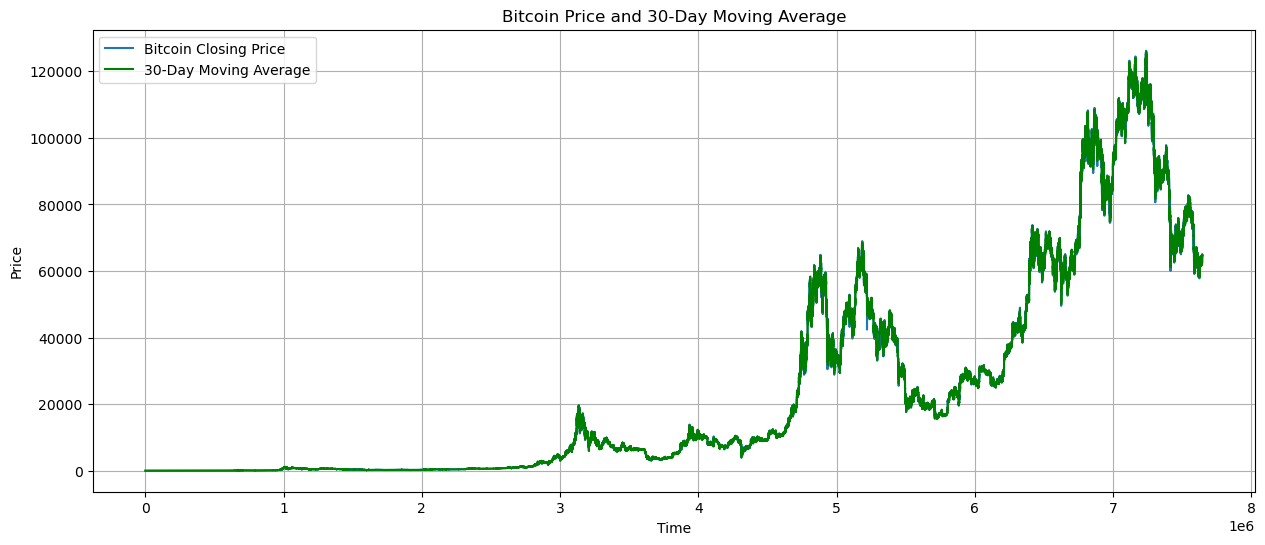

In [16]:
# 30-Day Moving Average

df["30-Day MA"] = df["Close"].rolling(window=30).mean()

plt.figure(figsize=(15,6))
plt.plot(df["Close"], label="Bitcoin Closing Price")
plt.plot(df["30-Day MA"], label="30-Day Moving Average", color="green")

plt.title("Bitcoin Price and 30-Day Moving Average")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

plt.show()

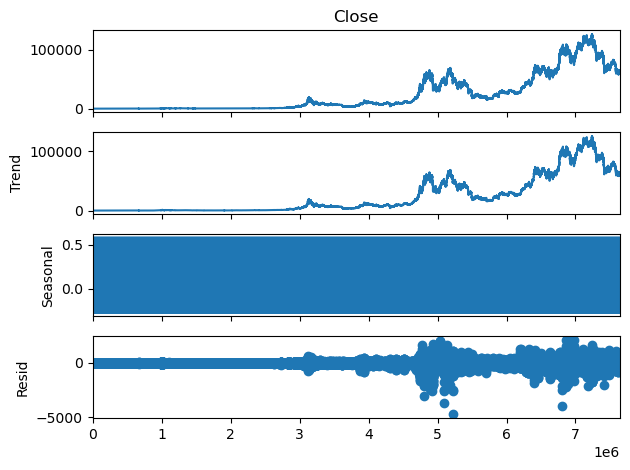

In [17]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Use the Close price for decomposition
result = seasonal_decompose(df["Close"], model="additive", period=30)

# Plot decomposition
result.plot()
plt.show()

In [19]:
from statsmodels.tsa.arima.model import ARIMA

data = df["Close"].tail(1000)

model = ARIMA(data, order=(5,1,0))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1000
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -5134.249
Date:                Thu, 16 Jul 2026   AIC                          10280.499
Time:                        15:06:28   BIC                          10309.939
Sample:                             0   HQIC                         10291.689
                               - 1000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0627      0.016     -3.843      0.000      -0.095      -0.031
ar.L2         -0.0398      0.020     -1.992      0.046      -0.079      -0.001
ar.L3          0.0612      0.023      2.697      0.0

In [20]:
# Predict the next 30 values
forecast = model_fit.forecast(steps=30)

print(forecast)

7645034    64694.893684
7645035    64695.398664
7645036    64694.993798
7645037    64694.936308
7645038    64695.008163
7645039    64694.970871
7645040    64694.969320
7645041    64694.980734
7645042    64694.977012
7645043    64694.976656
7645044    64694.977953
7645045    64694.977452
7645046    64694.977361
7645047    64694.977513
7645048    64694.977455
7645049    64694.977443
7645050    64694.977462
7645051    64694.977456
7645052    64694.977454
7645053    64694.977457
7645054    64694.977456
7645055    64694.977456
7645056    64694.977456
7645057    64694.977456
7645058    64694.977456
7645059    64694.977456
7645060    64694.977456
7645061    64694.977456
7645062    64694.977456
7645063    64694.977456
Name: predicted_mean, dtype: float64


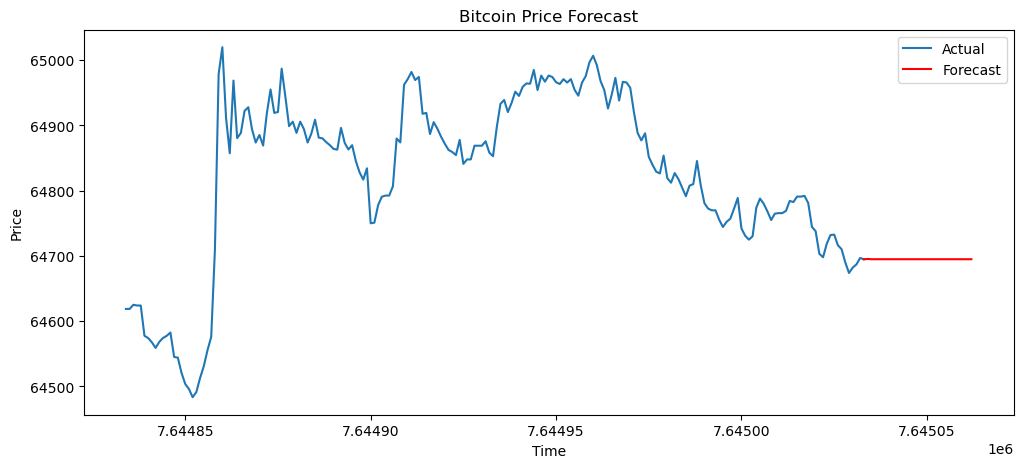

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df["Close"].tail(200), label="Actual")
plt.plot(range(len(df)-1, len(df)-1+30), forecast, color="red", label="Forecast")
plt.title("Bitcoin Price Forecast")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

## Conclusion

An ARIMA (5,1,0) model was developed to forecast Bitcoin prices using historical cryptocurrency data. The model successfully captured the recent trend and generated forecasts for future values. This project demonstrates the application of time series forecasting techniques for cryptocurrency price prediction.